In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [4]:
full_train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:07<00:00, 3.32MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.92MB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.66MB/s]


In [5]:
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

In [6]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [7]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

In [8]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

In [9]:
images, labels = next(iter(train_loader))

print("Shape des images :", images.shape)
print("Shape des labels :", labels.shape)

Shape des images : torch.Size([64, 1, 28, 28])
Shape des labels : torch.Size([64])


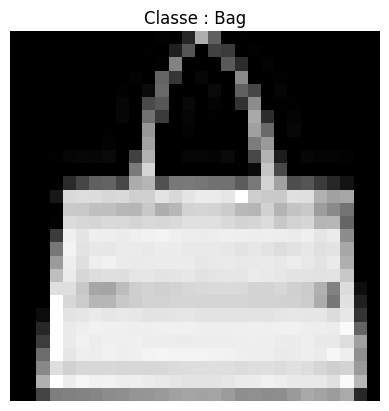

In [10]:
image = images[0].squeeze().cpu().numpy()
label = labels[0].item()

image = image * 0.5 + 0.5

plt.imshow(image, cmap="gray")
plt.title(f"Classe : {class_names[label]}")
plt.axis("off")
plt.show()

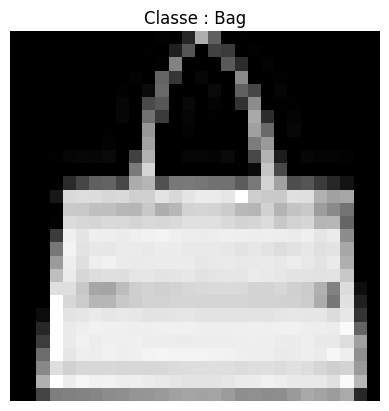

In [11]:
image = images[0].squeeze().cpu().numpy()
label = labels[0].item()

image = image * 0.5 + 0.5

plt.imshow(image, cmap="gray")
plt.title(f"Classe : {class_names[label]}")
plt.axis("off")
plt.show()

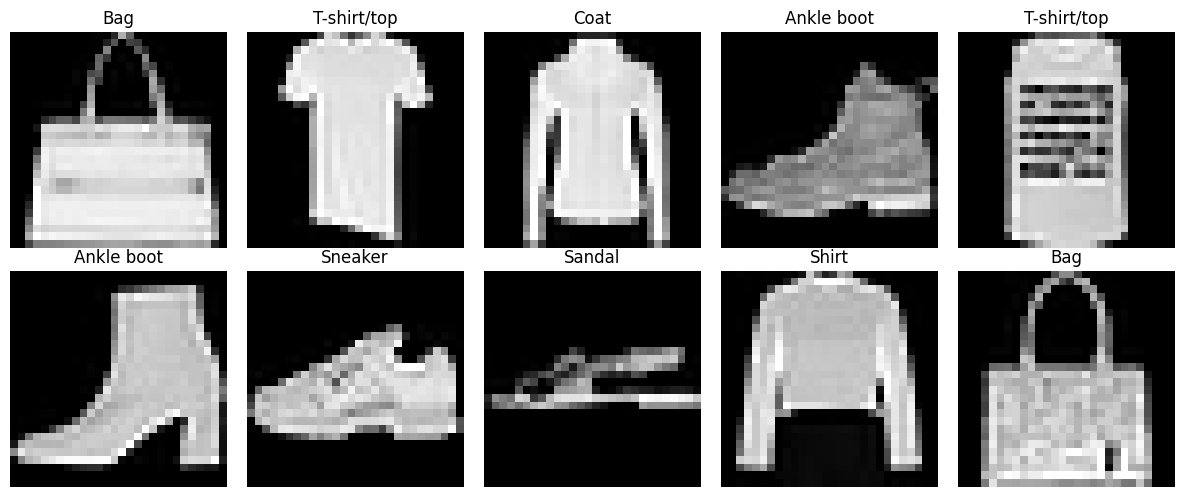

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().cpu().numpy()
    img = img * 0.5 + 0.5
    lbl = labels[i].item()

    ax.imshow(img, cmap="gray")
    ax.set_title(class_names[lbl])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
model = CNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [14]:
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    loss = running_loss / total
    accuracy = correct / total

    return loss, accuracy

In [15]:
num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_acc = 0.0
best_model_state = None

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/10 | Train Loss: 0.5001 | Train Acc: 0.8207 | Val Loss: 0.3341 | Val Acc: 0.8785
Epoch 2/10 | Train Loss: 0.3216 | Train Acc: 0.8824 | Val Loss: 0.2831 | Val Acc: 0.8980
Epoch 3/10 | Train Loss: 0.2703 | Train Acc: 0.9023 | Val Loss: 0.2492 | Val Acc: 0.9102
Epoch 4/10 | Train Loss: 0.2383 | Train Acc: 0.9147 | Val Loss: 0.2379 | Val Acc: 0.9123
Epoch 5/10 | Train Loss: 0.2124 | Train Acc: 0.9207 | Val Loss: 0.2407 | Val Acc: 0.9127
Epoch 6/10 | Train Loss: 0.1960 | Train Acc: 0.9272 | Val Loss: 0.2241 | Val Acc: 0.9183
Epoch 7/10 | Train Loss: 0.1765 | Train Acc: 0.9347 | Val Loss: 0.2201 | Val Acc: 0.9217
Epoch 8/10 | Train Loss: 0.1612 | Train Acc: 0.9396 | Val Loss: 0.2297 | Val Acc: 0.9197
Epoch 9/10 | Train Loss: 0.1473 | Train Acc: 0.9439 | Val Loss: 0.2191 | Val Acc: 0.9270
Epoch 10/10 | Train Loss: 0.1354 | Train Acc: 0.9493 | Val Loss: 0.2340 | Val Acc: 0.9215


In [18]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"Meilleure validation accuracy : {best_val_acc:.4f}")

Meilleure validation accuracy : 0.9283


In [21]:
test_loss, test_acc = evaluate_model(model, test_loader, criterion, device)

print(f"Loss sur le jeu de test : {test_loss:.4f}")
print(f"Précision sur le jeu de test : {test_acc * 100:.2f}%")

Loss sur le jeu de test : 0.2634
Précision sur le jeu de test : 91.73%


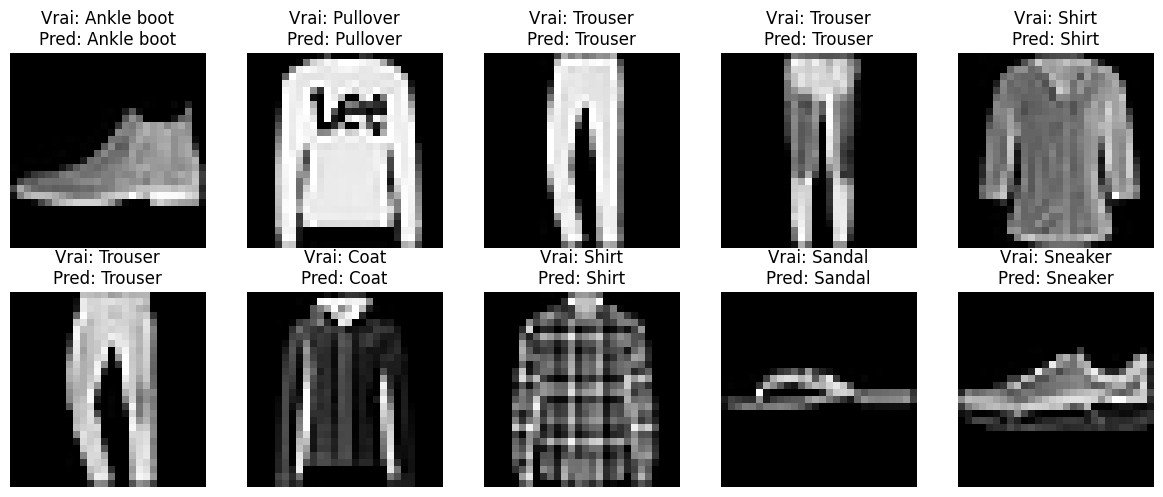

In [22]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    img = img * 0.5 + 0.5

    true_label = class_names[labels[i].item()]
    pred_label = class_names[preds[i].item()]

    ax.imshow(img, cmap="gray")
    ax.set_title(f"Vrai: {true_label}\nPred: {pred_label}")
    ax.axis("off")

plt.tight_layout()
plt.show()